# Panama Electricity Demand Forecasting : RNN vs. LSTM vs. Ensemble

**Contents**
1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Train/Test Split & Scaling
7. Sequence Creation (Multi-Step)
8. Model Architectures
9. Hyperparameters
10. Reproducibility
11. Train RNN and LSTM
12. Evaluate RNN and LSTM
13. Ensemble
14. Final Comparison
15. Save Models & Scalers


## 1. Import Libraries

In [1]:
import random
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

from warnings import simplefilter
simplefilter("ignore")

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)


## 2. Load Dataset

In [2]:
DATA_PATH = "data/train.csv"     # relative to the project root
MODELS_DIR = Path("models")

df = pd.read_csv(DATA_PATH, parse_dates=["datetime"], dayfirst=True)
df = df.sort_values("datetime").reset_index(drop=True)
print(df.shape)
df.head()


(43775, 17)


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


## 3. Data Cleaning

In [3]:
print(f"Shape: {df.shape}")
df.info()
df.describe()

Shape: (43775, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43775 entries, 0 to 43774
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    43775 non-null  datetime64[ns]
 1   nat_demand  43775 non-null  float64       
 2   T2M_toc     43775 non-null  float64       
 3   QV2M_toc    43775 non-null  float64       
 4   TQL_toc     43775 non-null  float64       
 5   W2M_toc     43775 non-null  float64       
 6   T2M_san     43775 non-null  float64       
 7   QV2M_san    43775 non-null  float64       
 8   TQL_san     43775 non-null  float64       
 9   W2M_san     43775 non-null  float64       
 10  T2M_dav     43775 non-null  float64       
 11  QV2M_dav    43775 non-null  float64       
 12  TQL_dav     43775 non-null  float64       
 13  W2M_dav     43775 non-null  float64       
 14  Holiday_ID  43775 non-null  int64         
 15  holiday     43775 non-null  int64         
 16  sch

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
count,43775,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000,43775.000000
mean,2017-07-03 00:00:00,1184.102195,27.381070,0.018372,0.082358,13.018476,26.869752,0.017909,0.109571,6.934124,24.678938,0.016912,0.148480,3.562928,0.730828,0.062501,0.739600
min,2015-01-03 01:00:00,85.192500,22.953455,0.012054,0.000000,0.008979,19.765222,0.010385,0.000009,0.060431,19.933740,0.009655,0.000051,0.015497,0.000000,0.000000,0.000000
25%,2016-04-03 00:30:00,1017.453350,26.168436,0.017337,0.028423,7.387169,24.767938,0.016707,0.040314,3.912895,22.951654,0.015867,0.079285,2.301747,0.000000,0.000000,0.000000
50%,2017-07-03 00:00:00,1173.251500,27.109338,0.018670,0.068237,11.767408,26.141260,0.018418,0.089752,5.888003,23.981989,0.017224,0.134277,3.408653,0.000000,0.000000,1.000000
75%,2018-10-01 23:30:00,1332.279950,28.521463,0.019549,0.120148,18.038599,28.642450,0.019265,0.161377,9.151058,26.174570,0.018092,0.204773,4.652970,0.000000,0.000000,1.000000
max,2019-12-31 23:00:00,1721.515700,35.039575,0.022690,0.521240,39.229726,39.063440,0.022011,0.484985,24.483937,34.216211,0.020958,0.477783,10.288902,22.000000,1.000000,1.000000
std,NaN,193.512875,1.652179,0.001587,0.065835,7.151448,2.960669,0.001853,0.086249,4.055238,2.374089,0.001566,0.088259,1.709116,3.244740,0.242067,0.438858


In [4]:
# Duplicate timestamps
print("Duplicate timestamps:", df["datetime"].duplicated().sum())

# Missing hours in the sequence
full_range = pd.date_range(df["datetime"].min(), df["datetime"].max(), freq="h")
missing_hours = full_range.difference(df["datetime"])
print("Missing timestamps:", len(missing_hours))

# Nulls
print("\nNulls per column:")
print(df.isnull().sum())

Duplicate timestamps: 0
Missing timestamps: 0

Nulls per column:
datetime      0
nat_demand    0
T2M_toc       0
QV2M_toc      0
TQL_toc       0
W2M_toc       0
T2M_san       0
QV2M_san      0
TQL_san       0
W2M_san       0
T2M_dav       0
QV2M_dav      0
TQL_dav       0
W2M_dav       0
Holiday_ID    0
holiday       0
school        0
dtype: int64


In [5]:
# Reindex to a strict hourly frequency and interpolate any missing hours
df = df.set_index("datetime").asfreq("h")
df["nat_demand"] = df["nat_demand"].interpolate(method="linear")
df = df.reset_index()

print(f"Missing values after cleaning: {df.isnull().sum().sum()}")


Missing values after cleaning: 0


## 4. Exploratory Data Analysis

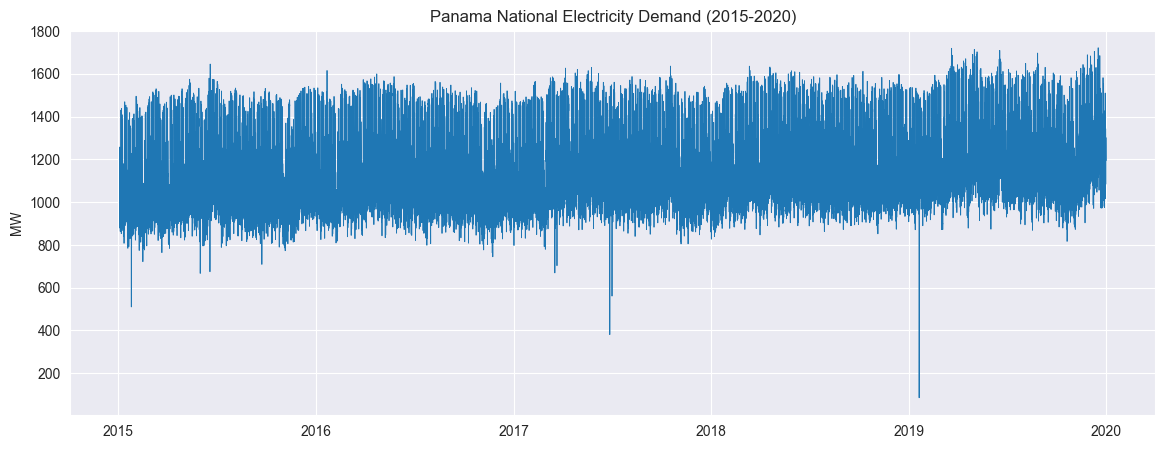

In [6]:
plt.plot(df["datetime"], df["nat_demand"], linewidth=0.6)
plt.title("Panama National Electricity Demand (2015-2020)")
plt.ylabel("MW")
plt.show()


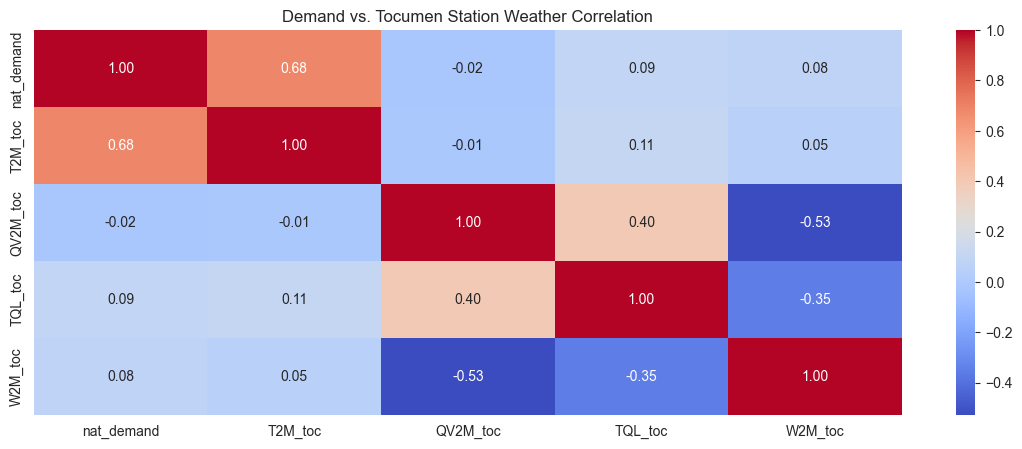

In [7]:
weather_cols = ["T2M_toc", "QV2M_toc", "TQL_toc", "W2M_toc"]
sns.heatmap(df[["nat_demand"] + weather_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Demand vs. Tocumen Station Weather Correlation")
plt.show()


## 5. Feature Engineering

In [8]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek

# Cyclical encoding so hour 23 and hour 0 read as adjacent, not distant
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Target first (column 0), then the 18 features the model sees
feature_cols = ["nat_demand", "T2M_toc", "QV2M_toc", "TQL_toc", "W2M_toc",
                 "T2M_san", "QV2M_san", "TQL_san", "W2M_san",
                 "T2M_dav", "QV2M_dav", "TQL_dav", "W2M_dav",
                 "holiday", "school", "hour_sin", "hour_cos", "dow_sin", "dow_cos"]

df_features = df[feature_cols].copy()
df_features.shape


(43775, 19)

## 6. Train/Test Split & Scaling

In [9]:
# Chronological 80/20 split -- no shuffling, since it's a time series
train_size = int(len(df_features) * 0.8)
train_df = df_features[:train_size]
test_df = df_features[train_size:]

# Fit scalers on train only, to avoid leaking test-period info into training
target_scaler = MinMaxScaler().fit(train_df[["nat_demand"]])
feat_scaler = MinMaxScaler().fit(train_df.iloc[:, 1:])

print(f"Train: {train_df.shape} | Test: {test_df.shape}")


Train: (35020, 19) | Test: (8755, 19)


## 7. Sequence Creation (Multi-Step)

In [10]:
SEQ_LEN = 24    # hours of history the model sees
PRED_LEN = 6    # hours ahead it forecasts (multi-step -- was a single hour before)


def create_sequences(data, seq_len, pred_len):
    """X: a seq_len window. y: the next pred_len values of column 0 (nat_demand)."""
    X, y = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len: i + seq_len + pred_len, 0])
    return np.array(X), np.array(y)


def prepare_data(data_df):
    scaled_target = target_scaler.transform(data_df[["nat_demand"]])
    scaled_feats = feat_scaler.transform(data_df.iloc[:, 1:])
    combined = np.hstack([scaled_target, scaled_feats])
    return create_sequences(combined, SEQ_LEN, PRED_LEN)


X_train, y_train = prepare_data(train_df)
X_test, y_test = prepare_data(test_df)
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")


X_train: (34991, 24, 19) | y_train: (34991, 6)


## 8. Model Architectures

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [12]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])   # last time step -> forecast vector


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


## 9. Hyperparameters

- **RNN : 20 epochs, no dropout.** A plain RNN has one gate per layer, so it converges quickly;
  more epochs and added dropout did not improve it further in testing.
- **LSTM : 40 epochs, dropout 0.2.** LSTM has four gated sub-networks per layer, so it needs a
  longer training budget to reach a comparable fit; once given that training time


In [13]:
HYPERPARAMS = {
    "RNN":  {"epochs": 20, "lr": 0.001},
    "LSTM": {"epochs": 40, "lr": 0.001, "dropout": 0.0},
}
HIDDEN_SIZE = 64
NUM_LAYERS = 2
BATCH_SIZE = 64


## 10. Reproducibility

In [14]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


## 11. Train RNN and LSTM

In [15]:
def train_model(model, train_loader, epochs, lr):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_loader))
    return losses


In [16]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float()),
    batch_size=BATCH_SIZE, shuffle=True,
)

models, histories = {}, {}

for name, ModelClass in [("RNN", RNNModel), ("LSTM", LSTMModel)]:
    set_seed(SEED)   # same seed before each model -> reproducible, comparable runs
    params = HYPERPARAMS[name]
    extra = {"dropout": params["dropout"]} if "dropout" in params else {}
    model = ModelClass(input_size=X_train.shape[2], hidden_size=HIDDEN_SIZE,
                        num_layers=NUM_LAYERS, output_size=PRED_LEN, **extra)

    print(f"Training {name} ({params['epochs']} epochs)...")
    histories[name] = train_model(model, train_loader, params["epochs"], params["lr"])
    models[name] = model

print("Done.")


Training RNN (20 epochs)...
Training LSTM (40 epochs)...
Done.


## 12. Evaluate RNN and LSTM

In [17]:
def evaluate_model(model, X_test, y_test):
    """Overall MAE/RMSE/MAPE/R2 in real MW, averaged across all 6 forecast hours."""
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_test).float()).numpy()

    n, h = y_test.shape
    preds_mw = target_scaler.inverse_transform(preds.reshape(-1, 1)).reshape(n, h)
    actual_mw = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(n, h)

    metrics = {
        "MAE": mean_absolute_error(actual_mw.flatten(), preds_mw.flatten()),
        "RMSE": np.sqrt(mean_squared_error(actual_mw.flatten(), preds_mw.flatten())),
        "MAPE": np.mean(np.abs((actual_mw - preds_mw) / actual_mw)) * 100,
        "R2": r2_score(actual_mw.flatten(), preds_mw.flatten()),
    }
    return metrics, preds_mw, actual_mw


results, predictions, actual_mw = {}, {}, None
for name, model in models.items():
    metrics, preds_mw, act_mw = evaluate_model(model, X_test, y_test)
    results[name] = metrics
    predictions[name] = preds_mw
    actual_mw = act_mw   # identical ground truth regardless of model

pd.DataFrame(results).T.round(3)


,MAE,RMSE,MAPE,R2
RNN,25.066,40.838,2.235,0.953
LSTM,27.014,40.933,2.389,0.953


## 13. Ensemble

In [18]:
# Simple average ensemble -- no extra weights to save, just average the
# two models' predictions at inference time.
ensemble_preds = (predictions["RNN"] + predictions["LSTM"]) / 2

results["Ensemble"] = {
    "MAE": mean_absolute_error(actual_mw.flatten(), ensemble_preds.flatten()),
    "RMSE": np.sqrt(mean_squared_error(actual_mw.flatten(), ensemble_preds.flatten())),
    "MAPE": np.mean(np.abs((actual_mw - ensemble_preds) / actual_mw)) * 100,
    "R2": r2_score(actual_mw.flatten(), ensemble_preds.flatten()),
}
predictions["Ensemble"] = ensemble_preds
pd.DataFrame(results).T.round(3)


,MAE,RMSE,MAPE,R2
RNN,25.066,40.838,2.235,0.953
LSTM,27.014,40.933,2.389,0.953
Ensemble,24.108,38.537,2.146,0.958


## 14. Final Comparison

             MAE    RMSE   MAPE     R2
RNN       25.066  40.838  2.235  0.953
LSTM      27.014  40.933  2.389  0.953
Ensemble  24.108  38.537  2.146  0.958


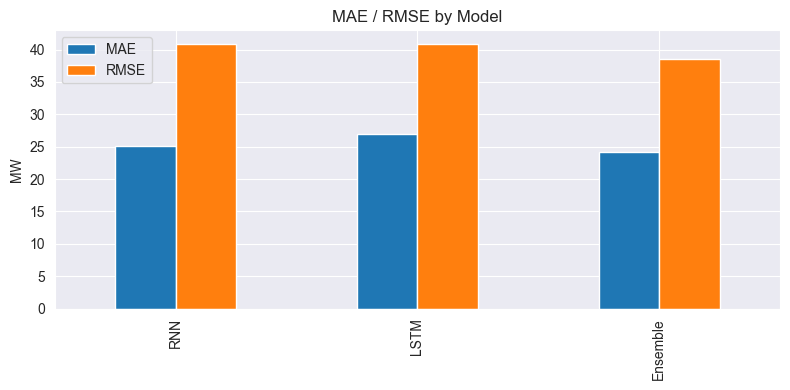

In [19]:
comparison_df = pd.DataFrame(results).T.round(3)
print(comparison_df)

comparison_df[["MAE", "RMSE"]].plot(kind="bar", figsize=(8, 4))
plt.title("MAE / RMSE by Model")
plt.ylabel("MW")
plt.tight_layout()
plt.show()


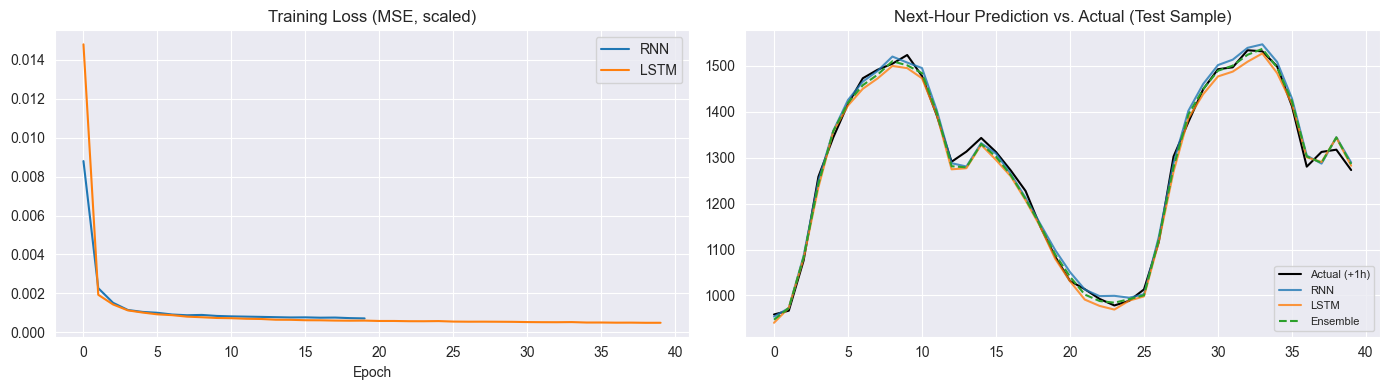

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, hist in histories.items():
    axes[0].plot(hist, label=name)
axes[0].set_title("Training Loss (MSE, scaled)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

sample = slice(0, 40)
axes[1].plot(actual_mw[sample, 0], label="Actual (+1h)", color="black")
axes[1].plot(predictions["RNN"][sample, 0], label="RNN", alpha=0.8)
axes[1].plot(predictions["LSTM"][sample, 0], label="LSTM", alpha=0.8)
axes[1].plot(predictions["Ensemble"][sample, 0], label="Ensemble", linestyle="--")
axes[1].set_title("Next-Hour Prediction vs. Actual (Test Sample)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 15. Save Models & Scalers

In [21]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(target_scaler, MODELS_DIR / "target_scaler.pkl")
joblib.dump(feat_scaler, MODELS_DIR / "feat_scaler.pkl")
torch.save(models["RNN"].state_dict(), MODELS_DIR / "rnn_model.pth")
torch.save(models["LSTM"].state_dict(), MODELS_DIR / "lstm_model.pth")

print("Saved: target_scaler.pkl, feat_scaler.pkl, rnn_model.pth, lstm_model.pth")


Saved: target_scaler.pkl, feat_scaler.pkl, rnn_model.pth, lstm_model.pth
